# Polymarket BTC 15-Min Data Explorer

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/")
df.sort_values("ts_ms", inplace=True, ignore_index=True)
df["ts"] = pd.to_datetime(df["ts_ms"], unit="ms", utc=True)

# Fee-adjusted columns (Polymarket 15-min crypto: rate=0.25, exponent=2)
def poly_fee(p):
    return 0.25 * (p * (1 - p)) ** 2

for side in ("up", "down"):
    ask = df[f"best_ask_{side}"]
    bid = df[f"best_bid_{side}"]
    df[f"fee_ask_{side}"] = poly_fee(ask)
    df[f"fee_bid_{side}"] = poly_fee(bid)
    df[f"eff_ask_{side}"] = ask + poly_fee(ask)
    df[f"eff_bid_{side}"] = bid - poly_fee(bid)
    df[f"eff_mid_{side}"] = (df[f"eff_bid_{side}"] + df[f"eff_ask_{side}"]) / 2
    df[f"eff_spread_{side}"] = df[f"eff_ask_{side}"] - df[f"eff_bid_{side}"]

markets = df["market_slug"].unique()

# Group windows into contiguous recording sessions.
# Extract unix timestamp from slug, sort, split on gaps > 15 min.
def _slug_ts(slug):
    return int(slug.rsplit("-", 1)[-1])

sorted_slugs = sorted(markets, key=_slug_ts)
sessions = []
current = [sorted_slugs[0]]
for prev, cur in zip(sorted_slugs, sorted_slugs[1:]):
    if _slug_ts(cur) - _slug_ts(prev) <= 900:  # contiguous (15 min apart)
        current.append(cur)
    else:
        sessions.append(current)
        current = [cur]
sessions.append(current)

print(f"Total: {len(df):,} rows  |  {len(df.columns)} columns  |  {len(markets)} markets  |  {len(sessions)} sessions")
for i, sess in enumerate(sessions):
    total = sum(len(df[df["market_slug"] == s]) for s in sess)
    t0 = df[df["market_slug"] == sess[0]]["ts"].iloc[0].strftime("%Y-%m-%d %H:%M")
    t1 = df[df["market_slug"] == sess[-1]]["ts"].iloc[-1].strftime("%H:%M")
    print(f"  Session {i+1}: {len(sess)} windows, {total:,} rows  ({t0} — {t1})")
    for slug in sess:
        print(f"    {slug}: {len(df[df['market_slug'] == slug]):,} rows")

Total: 114,214 rows  |  87 columns  |  18 markets  |  2 sessions
  Session 1: 4 windows, 21,762 rows  (2026-02-21 00:30 — 01:17)
    btc-updown-15m-1771633800: 7,153 rows
    btc-updown-15m-1771634700: 7,150 rows
    btc-updown-15m-1771635600: 7,151 rows
    btc-updown-15m-1771636500: 308 rows
  Session 2: 14 windows, 92,452 rows  (2026-02-22 02:19 — 05:39)
    btc-updown-15m-1771726500: 3,874 rows
    btc-updown-15m-1771727400: 7,149 rows
    btc-updown-15m-1771728300: 7,150 rows
    btc-updown-15m-1771729200: 7,149 rows
    btc-updown-15m-1771730100: 7,150 rows
    btc-updown-15m-1771731000: 7,149 rows
    btc-updown-15m-1771731900: 7,151 rows
    btc-updown-15m-1771732800: 7,154 rows
    btc-updown-15m-1771733700: 7,149 rows
    btc-updown-15m-1771734600: 7,148 rows
    btc-updown-15m-1771735500: 7,171 rows
    btc-updown-15m-1771736400: 7,184 rows
    btc-updown-15m-1771737300: 7,184 rows
    btc-updown-15m-1771738200: 2,690 rows


## Chainlink BTC Price

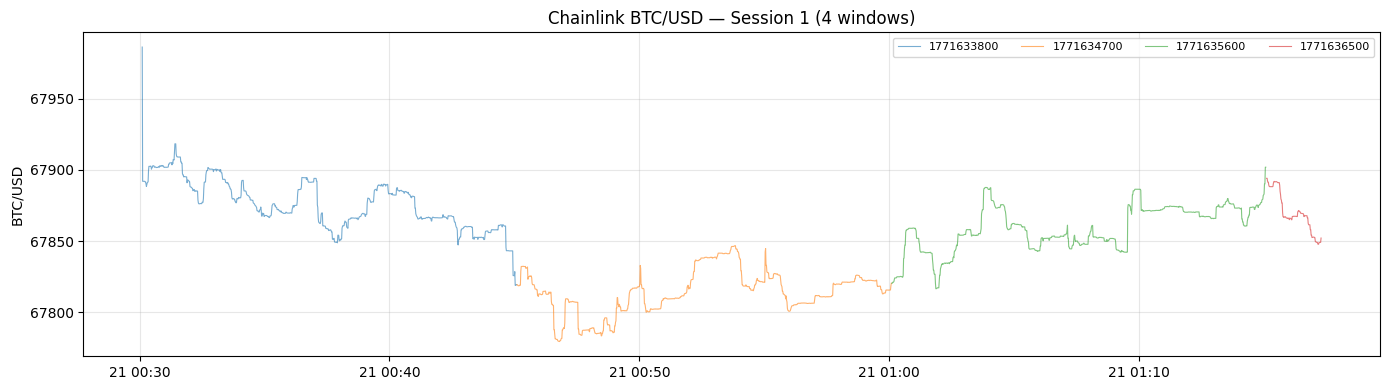

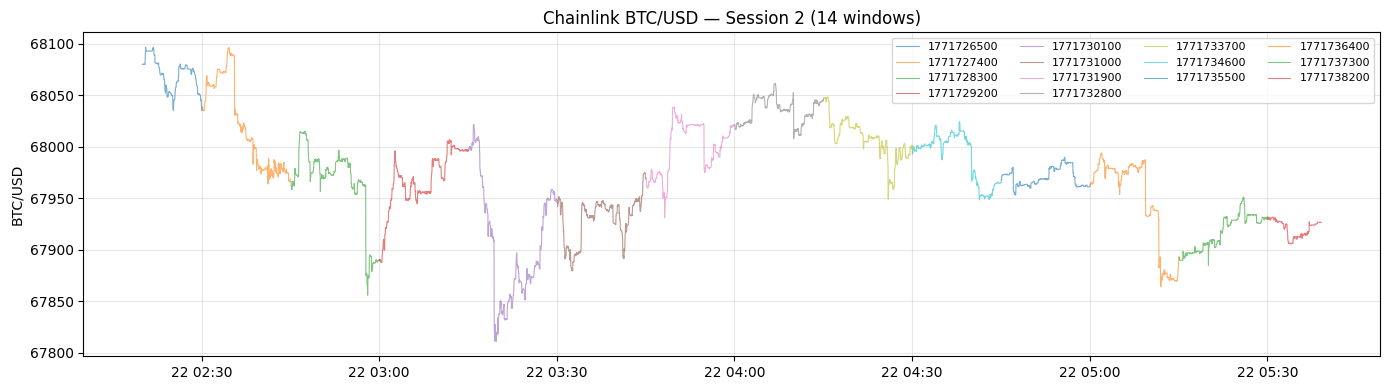

In [3]:
for i, sess in enumerate(sessions):
    fig, ax = plt.subplots(figsize=(14, 4))
    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax.plot(m["ts"], m["chainlink_btc"], linewidth=0.8, alpha=0.6, label=slug.split("15m-")[1])
    ax.set_ylabel("BTC/USD")
    ax.set_title(f"Chainlink BTC/USD — Session {i+1} ({len(sess)} windows)")
    ax.legend(fontsize=8, ncol=min(len(sess), 4))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Best Bid / Ask (Up outcome)

In [ ]:
for i, sess in enumerate(sessions):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax1.plot(m["ts"], m["best_bid_up"], alpha=0.5, color="C0")
        ax1.plot(m["ts"], m["best_ask_up"], alpha=0.5, color="C1")
        ax1.fill_between(m["ts"], m["best_bid_up"], m["best_ask_up"], alpha=0.1)
    ax1.set_ylabel("Price")
    ax1.set_title(f"Up Outcome: Raw Bid / Ask — Session {i+1}")
    ax1.grid(True, alpha=0.3)

    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax2.plot(m["ts"], m["eff_bid_up"], alpha=0.5, color="C0")
        ax2.plot(m["ts"], m["eff_ask_up"], alpha=0.5, color="C1")
        ax2.fill_between(m["ts"], m["eff_bid_up"], m["eff_ask_up"], alpha=0.1, color="C3")
    ax2.set_ylabel("Price")
    ax2.set_title(f"Up Outcome: Fee-Adjusted Bid / Ask — Session {i+1}")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Mid Price & Spread

In [ ]:
for i, sess in enumerate(sessions):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax1.plot(m["ts"], m["eff_mid_up"], linewidth=0.8, alpha=0.5)
        ax1.plot(m["ts"], m["eff_mid_down"], linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Mid Price")
    ax1.set_title(f"Fee-Adjusted Mid Price (Up & Down) — Session {i+1}")
    ax1.grid(True, alpha=0.3)

    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax2.plot(m["ts"], m["eff_spread_up"], linewidth=0.8, alpha=0.5)
        ax2.plot(m["ts"], m["eff_spread_down"], linewidth=0.8, alpha=0.5)
    ax2.set_ylabel("Spread")
    ax2.set_title(f"Fee-Adjusted Spread (Up & Down) — Session {i+1}")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Book Imbalance (Top 5 Levels)

In [ ]:
for i, sess in enumerate(sessions):
    fig, ax = plt.subplots(figsize=(14, 4))
    for slug in sess:
        m = df[df["market_slug"] == slug]
        ax.plot(m["ts"], m["imbalance5_up"], linewidth=0.8, alpha=0.5)
        ax.plot(m["ts"], m["imbalance5_down"], linewidth=0.8, alpha=0.5)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Imbalance (bid-ask)/(bid+ask)")
    ax.set_title(f"Order Book Imbalance — Session {i+1} ({len(sess)} windows)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Single Window Deep Dive

Window: btc-updown-15m-1771636500
Rows: 308  |  Duration: 894s


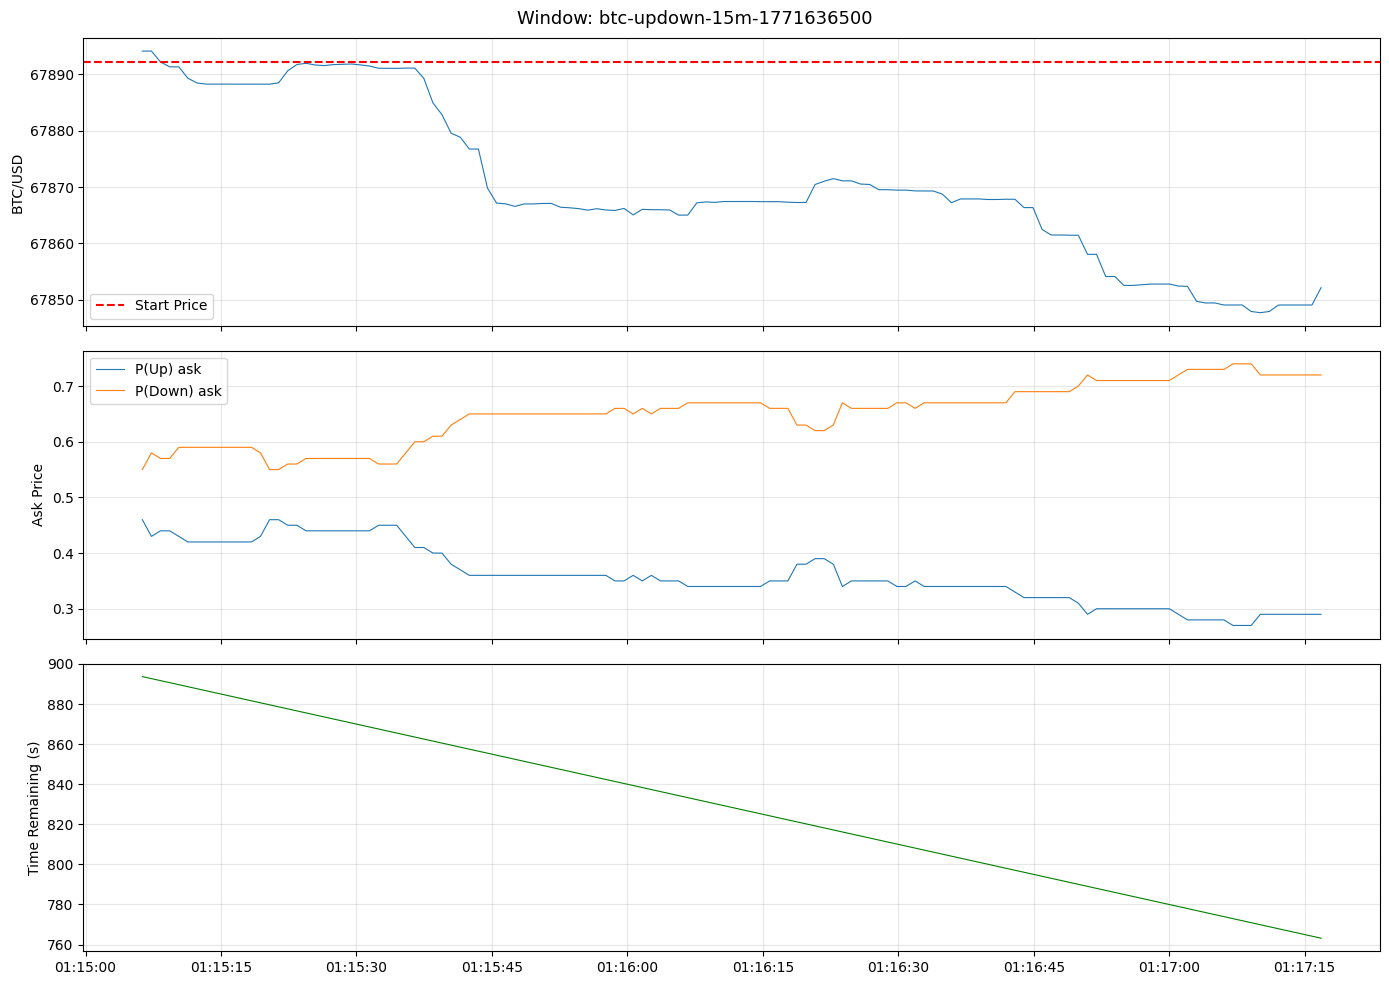

In [6]:
# Pick the latest window
latest = df[df["market_slug"] == df["market_slug"].iloc[-1]].copy()
print(f"Window: {latest['market_slug'].iloc[0]}")
print(f"Rows: {len(latest)}  |  Duration: {latest['time_remaining_s'].max():.0f}s")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(latest["ts"], latest["chainlink_btc"], linewidth=0.8)
if latest["window_start_price"].notna().any():
    axes[0].axhline(latest["window_start_price"].dropna().iloc[0], color="red", linestyle="--", label="Start Price")
axes[0].set_ylabel("BTC/USD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(latest["ts"], latest["best_ask_up"], label="P(Up) ask", linewidth=0.8)
axes[1].plot(latest["ts"], latest["best_ask_down"], label="P(Down) ask", linewidth=0.8)
axes[1].set_ylabel("Ask Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(latest["ts"], latest["time_remaining_s"], linewidth=0.8, color="green")
axes[2].set_ylabel("Time Remaining (s)")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Window: {latest['market_slug'].iloc[0]}", fontsize=13)
plt.tight_layout()
plt.show()

## Summary Stats

In [7]:
df[["best_bid_up", "best_ask_up", "spread_up", "mid_up",
    "eff_bid_up", "eff_ask_up", "eff_spread_up", "eff_mid_up",
    "fee_ask_up", "fee_bid_up",
    "best_bid_down", "best_ask_down", "spread_down", "mid_down",
    "eff_bid_down", "eff_ask_down", "eff_spread_down", "eff_mid_down",
    "chainlink_btc"]].describe().round(4)

,best_bid_up,best_ask_up,spread_up,mid_up,eff_bid_up,eff_ask_up,eff_spread_up,eff_mid_up,fee_ask_up,fee_bid_up,best_bid_down,best_ask_down,spread_down,mid_down,eff_bid_down,eff_ask_down,eff_spread_down,eff_mid_down,chainlink_btc
count,21728.000,21618.0000,21584.0000,21584.0000,21728.0000,21618.0000,21584.0000,21584.0000,21618.0000,21728.0000,21618.0000,21728.000,21584.0000,21584.0000,21618.0000,21728.0000,21584.0000,21584.0000,21762.0000
mean,0.525,0.5320,0.0109,0.5274,0.5127,0.5444,0.0357,0.5274,0.0123,0.0123,0.4680,0.475,0.0109,0.4726,0.4556,0.4873,0.0357,0.4726,67849.7161
std,0.180,0.1775,0.0041,0.1765,0.1810,0.1766,0.0084,0.1764,0.0038,0.0039,0.1775,0.180,0.0041,0.1765,0.1766,0.1810,0.0084,0.1763,33.7410
min,0.010,0.0100,0.0100,0.0150,0.0100,0.0100,0.0101,0.0150,0.0000,0.0000,0.0100,0.010,0.0000,0.0150,0.0100,0.0100,0.0048,0.0150,67779.3939
25%,0.390,0.4000,0.0100,0.3950,0.3759,0.4144,0.0325,0.3951,0.0106,0.0110,0.3300,0.330,0.0100,0.3350,0.3178,0.3422,0.0325,0.3352,67820.3450
50%,0.510,0.5200,0.0100,0.5150,0.4944,0.5356,0.0380,0.5150,0.0139,0.0136,0.4800,0.490,0.0100,0.4850,0.4644,0.5056,0.0380,0.4850,67852.9120
75%,0.670,0.6700,0.0100,0.6650,0.6578,0.6822,0.0409,0.6648,0.0153,0.0153,0.6000,0.610,0.0100,0.6050,0.5856,0.6241,0.0409,0.6049,67875.1447
max,0.990,0.9900,0.1000,0.9850,0.9900,0.9900,0.1233,0.9850,0.0156,0.0156,0.9900,0.990,0.1000,0.9850,0.9900,0.9900,0.1233,0.9850,67986.3801
